In [2]:
import numpy as np 
import scipy 

data_dict = scipy.io.loadmat("/home/tp526/neuraloperator/data/burgers_pino_x80_t81.mat")

nt, nx = data_dict['output'].shape[1:]  # example grid size

mask = np.zeros((nt, nx), dtype=bool)

# Randomly choose 1000 unique flat indices
indices = np.random.choice(nt * nx, size=1000, replace=False)

# Set those positions to True
mask.flat[indices] = True

# Save
data_dict['mask'] = mask 

scipy.io.savemat("/home/tp526/neuraloperator/data/burgers_pino_x80_t81_mask.mat", data_dict, do_compression=True)

In [24]:
import numpy as np
import scipy.io

data_dict = scipy.io.loadmat("/home/tp526/neuraloperator/data/burgers_pino_x80_t81.mat")
nt, nx = data_dict['output'].shape[1:]

mask = np.zeros((nt, nx), dtype=bool)

# Only sample from interior rows [1:, :], excluding the first row
interior_size = (nt - 1) * nx
indices = np.random.choice(interior_size, size=100, replace=False)

# Offset the flat indices to skip the first row
rows = indices // nx + 1  # shift row index by 1
cols = indices % nx

mask[rows, cols] = True
mask[0, :] = True

# Save
data_dict['mask'] = mask
scipy.io.savemat(
    "/home/tp526/neuraloperator/data/burgers_pino_x80_t81_100_pts.mat",
    data_dict,
    do_compression=True
)

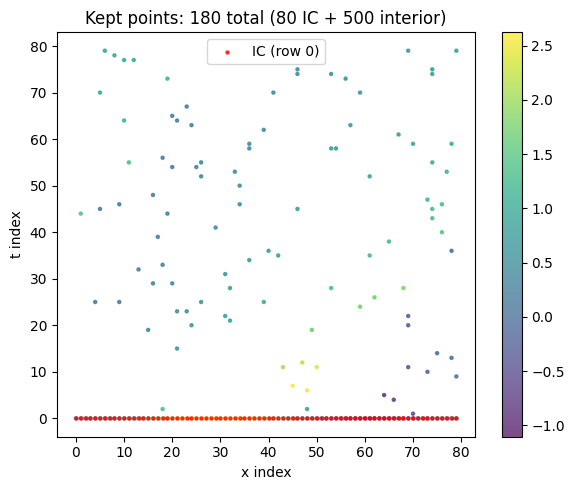

In [26]:
import matplotlib.pyplot as plt

rows_all, cols_all = np.where(mask)

plt.figure(figsize=(6, 5))

sc = plt.scatter(cols_all, rows_all, s=5, c=data_dict['output'][0][mask], alpha=0.7)
plt.scatter(np.arange(nx), np.zeros(nx), s=5, c='red', alpha=0.7, label='IC (row 0)')

plt.xlabel("x index")
plt.ylabel("t index")
plt.title(f"Kept points: {mask.sum()} total ({nx} IC + 500 interior)")
plt.legend()
plt.colorbar(sc)  # explicitly pass the scatter handle
plt.tight_layout()
plt.show()

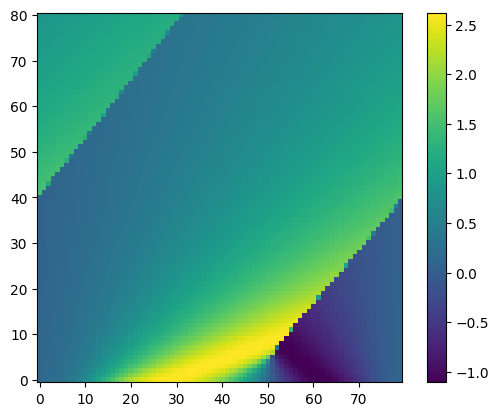

In [23]:
plt.imshow(data_dict['output'][0], origin="lower")
plt.colorbar()

In [18]:
np.max(data_dict['output'][1][mask])

np.float64(1.49057736992836)